# Simulations and testing

- Simulations are based on the `simulation_master.py` module. 
- All simulations are versions of AR(1) models.
- This is notebook is a guide to simulate a series, calculate GSADF, SADF and ADF test statistics, simulate critical values, compute and plot BSADF test and do the Monte carlo simulation study. 
- This notebook focuses on a simple random walk. Copy and paste the notebook and tweak the bubble process to get another simulation and the above calculations for it. 

First we import relevant libraries and the module file.

In [2]:
# to run R code
%load_ext rpy2.ipython

# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
import sys
import importlib

# add path to the module
sys.path.append(os.path.abspath(".."))

# import functions
from simulation import simulation_master

# reload functions
importlib.reload(simulation_master)

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <BBF229FE-E7FC-30D6-AD24-713D50386A7C> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


<module 'simulation.simulation_master' from '/Users/emilrand/Desktop/ku/Bachelor/6. semester/ba/ba_repo/simulation/simulation_master.py'>

### Random walk with with drift - 3 bubbles (simulating dot-com, corona, and AI)

If we define bubble periods as:

- dot-com bubble: january 1995 -> october 2002
- covid bubble: april 2020 -> july 2021
- ai bubble: january 2023 -> december 2025

And the sample length as januar 1990 -> december 2025, then there are with monthly data: $(2025 - 1990 + 1)\cdot 12 = 432$ observations. Using the periods as above we get:

- dot-com bubble: 61 -> 154
- covid bubble: 364 -> 382
- ai bubble: 397 -> 432

### Late bubble example

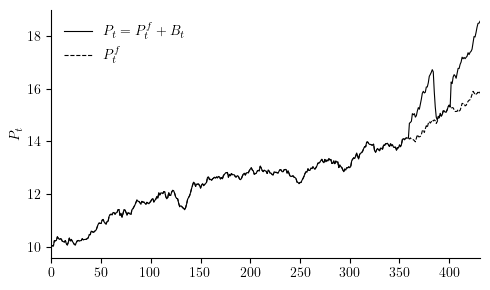

In [3]:
# late bubble

Pf_latebubbles, B_latebubbles, P_latebubbles = simulation_master.simulate_price_with_bubbles(
    
    # Sample size
    T = 432,
    
    # Fundamental component
    rho_f = 1.0,
    mu_f = 0.01,
    sigma_f = 0.08,
    Pf0 = 10.0,

    # Bubble component
    include_bubble = True,
    R = 0.04,
    sigma_b = 0.1,
    omega = 0.6,
    B0 = 0.0,

    # covid
    tau_s1 = 360,
    tau_e1 = 384,
    B0_1 = 0.6,
    # ai
    tau_s2 = 402,
    tau_e2 = 432,
    B0_2 = 1.0,

    # tau_s3=80,
    # tau_e3=130,
    # B0_3=0.3,

    # seed
    seed = 5,

)

# font
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

# plot
plt.figure(figsize=(5, 3))
plt.plot(P_latebubbles.index, P_latebubbles.values, color='black', linewidth=0.8, ls='-', label=r'$P_t = P_t^f + B_t$')
plt.plot(Pf_latebubbles.index, Pf_latebubbles.values, color='black', linewidth=0.8, ls='--', label=r'$P_t^f$')
plt.ylabel(r'$P_t$')

# formatting
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
# plt.grid(True, alpha=0.5, linestyle='--')
plt.legend(frameon=False, loc='upper left')
plt.xlim(P_latebubbles.index.min(), P_latebubbles.index.max())

# cleaner axes
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# save and show
plt.savefig('plots/P_latebubbles.pdf')
P_latebubbles = P_latebubbles.rename('P_latebubbles')
P_latebubbles.to_csv('data/P_latebubbles.csv', index=False)
plt.show()